# Leitura de Dados

In [ ]:
!pip install scikeras

In [ ]:
pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
# Reprodutibilidade
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'
import random
random.seed(1)
import numpy as np
np.random.seed(1)
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()
tf.random.set_seed(1)

In [ ]:
import pandas as pd

In [ ]:
dados_central = pd.read_csv("/content/tpm_unstranded.csv")

In [ ]:
dados_central['subtipo2'].value_counts()

,count
subtipo2,
BRCA.LumA,580
BRCA.LumB,219
BRCA.Basal,191
BRCA.Her2,82


### Quantidade de amostras por classe em cada cliente

In [ ]:
contagens = dados_central.groupby(['tss', 'subtipo2']).size().to_frame(name = 'Count').reset_index().pivot(index = 'tss', columns='subtipo2', values='Count')
contagens = contagens.fillna(value=0)
contagens['Total'] = contagens['BRCA.Basal'] +  contagens['BRCA.Her2'] + contagens['BRCA.LumA'] + contagens['BRCA.LumB']

### Clientes com 3 ou mais amostras em cada classe são incluídos no treinamento do AF

In [ ]:
contagens['Função'] = contagens.gt(2).all(axis = 1).replace({True : 'Treino e Teste', False: 'Teste'})
contagens = contagens.sort_values(by= ['Função', 'Total'], ascending=False)
contagens['index'] = list(range(1,len(contagens)+1))
contagens = contagens.reset_index()

In [ ]:
tt_tss = contagens.loc[contagens['Função'] == 'Treino e Teste', ['index','tss']]
t_tss = contagens.loc[contagens['Função'] == 'Teste', ['index','tss']]

In [ ]:
contagens

subtipo2,tss,BRCA.Basal,BRCA.Her2,BRCA.LumA,BRCA.LumB,Total,Função,index
0,BH,20.0,8.0,100.0,25.0,153.0,Treino e Teste,1
1,A2,24.0,8.0,44.0,19.0,95.0,Treino e Teste,2
2,E2,18.0,6.0,53.0,15.0,92.0,Treino e Teste,3
3,A8,5.0,9.0,36.0,33.0,83.0,Treino e Teste,4
4,D8,11.0,6.0,37.0,23.0,77.0,Treino e Teste,5
5,AR,16.0,4.0,31.0,15.0,66.0,Treino e Teste,6
6,B6,15.0,4.0,30.0,8.0,57.0,Treino e Teste,7
7,C8,6.0,15.0,12.0,14.0,47.0,Treino e Teste,8
8,AC,7.0,3.0,32.0,3.0,45.0,Treino e Teste,9
9,AO,8.0,3.0,20.0,11.0,42.0,Treino e Teste,10


## Divisão em Treino (60%), Validação (20%) e Teste (20%) feita de forma estratificada para garantir todas as classes em todas as divisões.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#endereco_pasta = '/content/tcga_clientes_treino_valid'
#os.makedirs(endereco_pasta, exist_ok=True)
#endereco_pasta = '/content/tcga_clientes_teste'
#os.makedirs(endereco_pasta, exist_ok=True)

In [ ]:
lista_conj_treino, lista_conj_valid, lista_conj_teste = [], [], []
for i in range(len(tt_tss['tss'])):
    dados_cliente = dados_central[dados_central['tss'] == tt_tss['tss'][i]]
    conj_treino_cliente, conj_teste_cliente = train_test_split(dados_cliente, test_size=0.2, random_state=i, stratify=dados_cliente['subtipo2'])
    conj_treino_cliente, conj_valid_cliente = train_test_split(conj_treino_cliente, test_size=0.25, random_state=1000+i, stratify=conj_treino_cliente['subtipo2'])
    #conj_treino_cliente.to_csv(f'{endereco_pasta}/fl_conj_treino_{tt_tss['tss'][i]}.csv', index = False)
    #conj_valid_cliente.to_csv(f'{endereco_pasta}/fl_conj_valid_{tt_tss['tss'][i]}.csv', index = False)
    #conj_teste_cliente.to_csv(f'{endereco_pasta}/fl_conj_test_{tt_tss['tss'][i]}.csv', index = False)
    lista_conj_treino.append(conj_treino_cliente)
    lista_conj_valid.append(conj_valid_cliente)
    lista_conj_teste.append(conj_teste_cliente)

In [ ]:
#from google.colab import files
#import shutil
#shutil.make_archive('/content/tcga_clientes_treino_valid', 'zip', endereco_pasta)
#files.download('/content/tcga_clientes_treino_valid.zip')
#shutil.make_archive('/content/tcga_clientes_teste', 'zip', endereco_pasta)
#files.download('/content/tcga_clientes_teste.zip')

In [ ]:
conj_treino = pd.concat(lista_conj_treino, ignore_index=True)
conj_valid = pd.concat(lista_conj_valid, ignore_index=True)
conj_teste = pd.concat(lista_conj_teste, ignore_index=True)

### Clientes que não participam do treino no AF são incluídos no conjunto de treino no AM. Dessa forma, os conjuntos de teste são iguais.

In [ ]:
for i in range(len(t_tss['tss'])):
    dados_cliente = dados_central[dados_central['tss'] == t_tss['tss'][i+11]]
    # dados_cliente.to_csv(f'fl_conj_total_{t_tss['tss'][i+11]}.csv', index = False)
    lista_conj_treino.append(dados_cliente)
conj_treino = pd.concat(lista_conj_treino, ignore_index=True)

### Pré-processamento

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
x_treino, y_treino = conj_treino.iloc[:, 5:], conj_treino['subtipo2']
x_valid, y_valid = conj_valid.iloc[:, 5:], conj_valid['subtipo2']
x_teste, y_teste = conj_teste.iloc[:, 5:], conj_teste['subtipo2']
ee = LabelEncoder()
y_treino_enc = ee.fit_transform(y_treino)
y_valid_enc = ee.transform(y_valid)
y_teste_enc = ee.transform(y_teste)

In [ ]:
x_treino.head(5)

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
0,41.1188,0.0000,124.4101,14.3066,14.4906,6.2360,24.2954,38.5906,23.0485,64.5171,...,0,0.0,0.3633,0,0.0,0.0000,33.9957,0,0.0558,0.4565
1,42.5004,0.1089,87.5495,16.0765,6.3399,9.1717,5.2868,68.9403,21.8102,24.2279,...,0,0.0,0.8460,0,0.0,0.0000,31.2631,0,0.0334,2.1525
2,44.7737,74.6146,100.0131,4.5859,1.9524,42.1021,129.8255,66.5986,17.4581,19.9378,...,0,0.0,0.0995,0,0.0,0.0158,8.4900,0,0.0393,0.0750
3,16.2476,1.0984,199.1859,13.9854,22.2571,16.9180,29.1286,39.3534,21.0698,83.8240,...,0,0.0,0.2489,0,0.0,0.0000,27.9628,0,0.0070,2.1311
4,30.3687,1.3891,62.0537,15.9735,3.0909,14.0569,13.4083,75.0596,9.8731,36.1460,...,0,0.0,0.1124,0,0.0,0.0000,13.5446,0,0.0866,0.6483


### Padronização dos dados

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
x_treino_sc = scaler.fit_transform(x_treino)
x_valid_sc = scaler.transform(x_valid)

### Análise de Componentes Principais

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(random_state=1)
x_treino_pca = pca.fit_transform(x_treino_sc)
x_valid_pca = pca.transform(x_valid_sc)

In [ ]:
import matplotlib.pyplot as plt

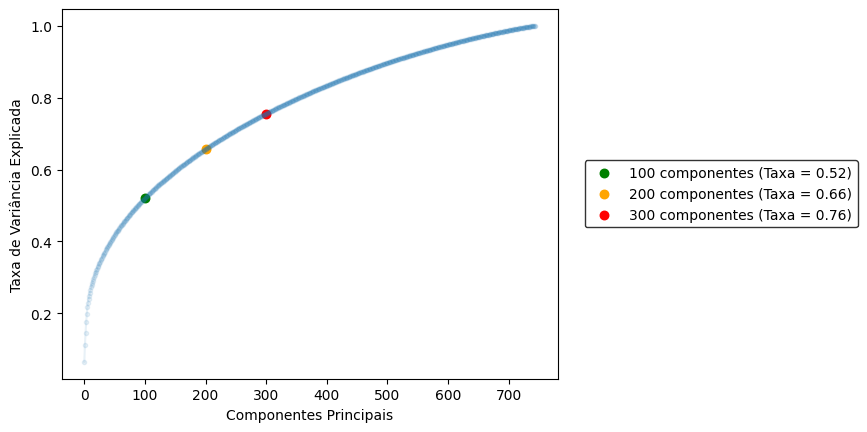

In [ ]:
plt.plot(pca.explained_variance_ratio_.cumsum(), marker = '.', alpha = 0.1)
plt.xlabel('Componentes Principais')
plt.ylabel('Taxa de Variância Explicada')
plt.scatter(x = 100, y = pca.explained_variance_ratio_.cumsum()[100], marker = '.', s = 150,  color = 'green', label = f'100 componentes (Taxa = {pca.explained_variance_ratio_.cumsum()[100]:.2f})')
plt.scatter(x = 200, y = pca.explained_variance_ratio_.cumsum()[200], marker = '.', s = 150,  color = 'orange', label = f'200 componentes (Taxa = {pca.explained_variance_ratio_.cumsum()[200]:.2f})')
plt.scatter(x = 300, y = pca.explained_variance_ratio_.cumsum()[300], marker = '.', s = 150,  color = 'red', label = f'300 componentes (Taxa = {pca.explained_variance_ratio_.cumsum()[300]:.2f})')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc = 'center left', edgecolor = 'black')
plt.show()

In [ ]:
pca = PCA(n_components=300, random_state = 1)
x_treino_pca = pca.fit_transform(x_treino_sc)
x_valid_pca = pca.transform(x_valid_sc)

### Autoencoder

In [ ]:
import keras
from keras import layers, regularizers, initializers

Testei autoencoder de 100, 200, 300, com L1(1e-4) e sem. 100 (sem) teve o menor val_loss

In [ ]:
input_layer = keras.Input(shape = (60660,))
encoded = layers.Dense(100, activation = 'relu',
                       kernel_initializer = initializers.GlorotUniform(seed=1),
                       bias_initializer = 'zeros')(input_layer)
decoded = layers.Dense(60660, activation='sigmoid',
                       kernel_initializer = initializers.GlorotUniform(seed=1),
                       bias_initializer = 'zeros')(encoded)
autoencoder = keras.Model(input_layer, decoded)
encoder = keras.Model(input_layer, encoded)
encoded_input = keras.Input(shape=(100,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))
autoencoder.compile(optimizer=keras.optimizers.SGD(learning_rate = 1e-4), loss='mse')
autoencoder.fit(x_treino_sc, x_treino_sc,
                epochs=5,
                batch_size=256,
                validation_data=(x_valid_sc, x_valid_sc),
                shuffle = False)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 1.1622 - val_loss: 5.0778
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 958ms/step - loss: 1.1622 - val_loss: 5.0778
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 764ms/step - loss: 1.1622 - val_loss: 5.0778
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 762ms/step - loss: 1.1622 - val_loss: 5.0778
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 725ms/step - loss: 1.1622 - val_loss: 5.0778


In [ ]:
x_treino_ac = encoder.predict(x_treino_sc)
x_valid_ac = encoder.predict(x_valid_sc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


### Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote_ac = SMOTE(random_state = 1, k_neighbors = 5)
x_treino_ac_resampled, y_treino_ac_resampled = smote_ac.fit_resample(x_treino_ac, y_treino)

In [ ]:
smote_pca = SMOTE(random_state = 1, k_neighbors = 5)
x_treino_pca_resampled, y_treino_pca_resampled = smote_pca.fit_resample(x_treino_pca, y_treino)

In [ ]:
smote_sc = SMOTE(random_state = 1, k_neighbors = 5)
x_treino_sc_resampled, y_treino_sc_resampled = smote_pca.fit_resample(x_treino_sc, y_treino)

# Grid Search

In [ ]:
from sklearn.model_selection import PredefinedSplit
import numpy as np
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from keras import layers, regularizers, initializers, Sequential, Input, optimizers, metrics

### Método de validação Holdout

In [ ]:
ps_pca = PredefinedSplit(np.hstack((np.ones(len(x_treino_pca))*(-1),np.ones(len(x_valid_pca))*0)))

### Função para gerar redes neurais para seleção de hiperparâmetros

In [ ]:
def get_clf(hidden_layer_sizes, hidden_layer_num, regularizer):
    model = Sequential()
    model.add(Input(shape=(300,)))
    for i in range(hidden_layer_num):
        model.add(
            layers.Dense(
                units=hidden_layer_sizes,
                activation='relu',
                kernel_regularizer = regularizer,
                kernel_initializer = initializers.GlorotUniform(seed=1),
                bias_initializer = 'zeros'
        )
    )
    model.add(layers.Dense(4, activation='softmax',
                                 kernel_initializer = initializers.GlorotUniform(seed=1),
                                 bias_initializer = 'zeros'))
    model.compile(
         optimizer = keras.optimizers.SGD(learning_rate=5e-4),
         loss='sparse_categorical_crossentropy',
         metrics=['accuracy']
    )
    return model

### Seleção de hiperparâmetros com dados tranformados por PCA

In [ ]:
model_params = {
    'log_reg': {
        'model': Pipeline([
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__C': [0.01, 0.1, 1, 10],
            'log_reg__penalty': ['l1', 'l2'],
            'log_reg__solver': ['saga'],
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100, 1000],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [1, 3, 5, 15]
        }
    },
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
    'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([
                           ('keras', KerasClassifier(model=get_clf,
                                                     random_state = 1,
                                                     loss='sparse_categorical_crossentropy',
                                                     optimizer='sgd',
                                                     verbose=False,
                                                     epochs = 15))]),
        'params':{
            'keras__model__hidden_layer_sizes': [16, 32, 64, 128],
            'keras__model__hidden_layer_num': [1, 2, 3, 4, 5],
            'keras__model__regularizer': [regularizers.L1(1e-2), regularizers.L1(1e-3), regularizers.L2(1e-2), regularizers.L2(1e-3)]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_pca, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_pca), pd.DataFrame(x_valid_pca)]), pd.concat([y_treino, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_pca = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_pca

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,model,best_score,best_params
0,log_reg,0.863579,"{'log_reg__C': 0.01, 'log_reg__penalty': 'l2',..."
1,svm,0.880540,"{'SVC__C': 100, 'SVC__kernel': 'rbf', 'SVC__ra..."
2,knn,0.697852,{'KNN__n_neighbors': 3}
3,naive_bayes,0.181545,{}
4,tree,0.643187,"{'dt__max_depth': 15, 'dt__min_samples_split':..."
5,random_forest,0.484587,"{'rf__max_depth': None, 'rf__min_samples_split..."
6,nn,0.810763,"{'keras__model__hidden_layer_num': 1, 'keras__..."


### Seleção de hiperparâmetros com dados transformados por PCA e Oversampling

In [ ]:
ps_pca_resampled = PredefinedSplit(np.hstack((np.ones(len(x_treino_pca_resampled))*(-1),np.ones(len(x_valid_pca))*0)))

In [ ]:
model_params = {
    'log_reg': {
        'model': Pipeline([
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__C': [0.01, 0.1, 1, 10],
            'log_reg__penalty': ['l1', 'l2'],
            'log_reg__solver': ['saga'],
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100, 1000],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [1, 3, 5, 15]
        }
    },
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
    'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([
                           ('keras', KerasClassifier(model=get_clf,
                                                     random_state = 1,
                                                     loss='sparse_categorical_crossentropy',
                                                     optimizer='sgd',
                                                     verbose=False,
                                                     epochs = 15))]),
        'params':{
            #'keras__model__learning_rate': [1e-2, 1e-3, 5e-4],
            'keras__model__hidden_layer_sizes': [16, 32, 64, 128],
            'keras__model__hidden_layer_num': [1, 2, 3, 4, 5],
            'keras__model__regularizer': [regularizers.L1(1e-2), regularizers.L1(1e-3), regularizers.L2(1e-2), regularizers.L2(1e-3)]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_pca_resampled, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_pca_resampled), pd.DataFrame(x_valid_pca)]), pd.concat([y_treino_pca_resampled, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_pca_os = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_pca_os

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,model,best_score,best_params
0,log_reg,0.844494,"{'log_reg__C': 0.01, 'log_reg__penalty': 'l2',..."
1,svm,0.887571,"{'SVC__C': 1, 'SVC__kernel': 'rbf', 'SVC__rand..."
2,knn,0.795825,{'KNN__n_neighbors': 5}
3,naive_bayes,0.341916,{}
4,tree,0.738097,"{'dt__max_depth': None, 'dt__min_samples_split..."
5,random_forest,0.867803,"{'rf__max_depth': None, 'rf__min_samples_split..."
6,nn,0.837004,"{'keras__model__hidden_layer_num': 1, 'keras__..."


In [ ]:
y_treino_pca_resampled_enc= ee.transform(y_treino_pca_resampled)

### Seleção de hiperparâmetros com dados tranformados por Autoencoder

In [ ]:
ps_ac = PredefinedSplit(np.hstack((np.ones(len(x_treino_ac))*(-1),np.ones(len(x_valid_ac))*0)))

In [ ]:
def get_clf_ac(hidden_layer_sizes, hidden_layer_num, regularizer):
    model = Sequential()
    model.add(Input(shape=(100,)))
    for i in range(hidden_layer_num):
        model.add(
            layers.Dense(
                units=hidden_layer_sizes,
                activation='relu',
                kernel_regularizer = regularizer,
                kernel_initializer = initializers.GlorotUniform(seed=1),
                bias_initializer = 'zeros'
        )
    )
    model.add(layers.Dense(4, activation='softmax',
                                 kernel_initializer = initializers.GlorotUniform(seed=1),
                                 bias_initializer = 'zeros'))
    model.compile(
         optimizer = keras.optimizers.SGD(learning_rate=5e-4),
         loss='sparse_categorical_crossentropy',
         metrics=['accuracy']
    )
    return model

In [ ]:
model_params = {
    'log_reg': {
        'model': Pipeline([
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__C': [0.01, 0.1, 1, 10],
            'log_reg__penalty': ['l1', 'l2'],
            'log_reg__solver': ['saga'],
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100, 1000],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [1, 3, 5, 15]
        }
    },
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
    'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([
                           ('keras', KerasClassifier(model=get_clf_ac,
                                                     random_state = 1,
                                                     loss='sparse_categorical_crossentropy',
                                                     optimizer='sgd',
                                                     verbose=False,
                                                     epochs = 15))]),
        'params':{
            #'keras__model__learning_rate': [1e-2, 1e-3, 5e-4],
            'keras__model__hidden_layer_sizes': [16, 32, 64, 128],
            'keras__model__hidden_layer_num': [1, 2, 3, 4, 5],
            'keras__model__regularizer':  [regularizers.L1(1e-2), regularizers.L1(1e-3), regularizers.L2(1e-2), regularizers.L2(1e-3)]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_ac, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_ac), pd.DataFrame(x_valid_ac)]), pd.concat([y_treino, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_ac = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_ac

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,model,best_score,best_params
0,log_reg,0.477485,"{'log_reg__C': 1, 'log_reg__penalty': 'l1', 'l..."
1,svm,0.519665,"{'SVC__C': 10, 'SVC__kernel': 'poly', 'SVC__ra..."
2,knn,0.386298,{'KNN__n_neighbors': 5}
3,naive_bayes,0.396066,{}
4,tree,0.402804,"{'dt__max_depth': 15, 'dt__min_samples_split':..."
5,random_forest,0.422408,"{'rf__max_depth': 10, 'rf__min_samples_split':..."
6,nn,0.313397,"{'keras__model__hidden_layer_num': 1, 'keras__..."


### Seleção de hiperparâmetros com dados tranformados por Autoencoder e Oversampling

In [ ]:
ps_ac_resampled = PredefinedSplit(np.hstack((np.ones(len(x_treino_ac_resampled))*(-1),np.ones(len(x_valid_ac))*0)))

In [ ]:
model_params = {
    'log_reg': {
        'model': Pipeline([
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__C': [0.01, 0.1, 1, 10],
            'log_reg__penalty': ['l1', 'l2'],
            'log_reg__solver': ['saga'],
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100, 1000],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [1, 3, 5, 15]
        }
    },
    'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
    'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([
                           ('keras', KerasClassifier(model=get_clf_ac,
                                                     random_state = 1,
                                                     loss='sparse_categorical_crossentropy',
                                                     optimizer='sgd',
                                                     verbose=False,
                                                     epochs = 15))]),
        'params':{
            #'keras__model__learning_rate': [1e-2, 1e-3, 5e-4],
            'keras__model__hidden_layer_sizes': [16, 32, 64, 128],
            'keras__model__hidden_layer_num': [1, 2, 3, 4, 5],
            'keras__model__regularizer': [regularizers.L1(1e-2), regularizers.L1(1e-3), regularizers.L2(1e-2), regularizers.L2(1e-3)]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_ac_resampled, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_ac_resampled), pd.DataFrame(x_valid_ac)]), pd.concat([y_treino_ac_resampled, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_ac_os = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_ac_os

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,model,best_score,best_params
0,log_reg,0.539996,"{'log_reg__C': 1, 'log_reg__penalty': 'l1', 'l..."
1,svm,0.531713,"{'SVC__C': 10, 'SVC__kernel': 'poly', 'SVC__ra..."
2,knn,0.356680,{'KNN__n_neighbors': 1}
3,naive_bayes,0.339781,{}
4,tree,0.363211,"{'dt__max_depth': 15, 'dt__min_samples_split':..."
5,random_forest,0.443210,"{'rf__max_depth': 10, 'rf__min_samples_split':..."
6,nn,0.299862,"{'keras__model__hidden_layer_num': 3, 'keras__..."


### Seleção de hiperparâmetros com dados padronizados (métodos que tiveram desempenho ruim e rodam nos dados padronizados em tempo não tão grande)

In [ ]:
ps_sc = PredefinedSplit(np.hstack((np.ones(len(x_treino_sc))*(-1),np.ones(len(x_valid_sc))*0)))

In [ ]:
model_params = {
        'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
        'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_sc, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_sc), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_sc = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_sc

,model,best_score,best_params
0,naive_bayes,0.229511,{}
1,tree,0.809765,"{'dt__max_depth': 10, 'dt__min_samples_split':..."
2,random_forest,0.869990,"{'rf__max_depth': None, 'rf__min_samples_split..."


### Seleção de hiperparâmetros com dados padronizados e Oversampling

In [ ]:
ps_sc_resampled = PredefinedSplit(np.hstack((np.ones(len(x_treino_sc_resampled))*(-1),np.ones(len(x_valid_sc))*0)))

In [ ]:
model_params = {
        'naive_bayes': {
        'model': Pipeline([
                           ('nb', GaussianNB())]),
        'params': {}
    },
        'tree': {
        'model': Pipeline([
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 3, 10, 15, None],
            'dt__min_samples_split': [2, 6, 10],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 3, 10, 15, None],
            'rf__min_samples_split': [2, 6, 10],
            'rf__random_state': [1]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps_sc_resampled, return_train_score=False, scoring = 'f1_macro')
    clf.fit(pd.concat([pd.DataFrame(x_treino_sc_resampled), pd.DataFrame(x_valid_sc)]), pd.concat([y_treino_sc_resampled, y_valid]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao_sc_os = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao_sc_os

,model,best_score,best_params
0,naive_bayes,0.229511,{}
1,tree,0.844364,"{'dt__max_depth': 3, 'dt__min_samples_split': ..."
2,random_forest,0.905411,"{'rf__max_depth': 10, 'rf__min_samples_split':..."


### Preparação dos dados para teste

In [ ]:
scaler_final = StandardScaler()
x_treino_sc_final = scaler_final.fit_transform(pd.concat([x_treino, x_valid]))
x_teste_sc_final = scaler_final.transform(x_teste)

pca = PCA(n_components=300, random_state = 1)
x_treino_pca_final = pca.fit_transform(x_treino_sc_final)
x_teste_pca_final = pca.transform(x_teste_sc_final)

input_layer = keras.Input(shape = (60660,))
encoded = layers.Dense(100, activation = 'relu',
                       kernel_initializer = initializers.GlorotUniform(seed=1),
                       bias_initializer = 'zeros')(input_layer)
decoded = layers.Dense(60660, activation='sigmoid',
                       kernel_initializer = initializers.GlorotUniform(seed=1),
                       bias_initializer = 'zeros')(encoded)
autoencoder = keras.Model(input_layer, decoded)
encoder = keras.Model(input_layer, encoded)
encoded_input = keras.Input(shape=(100,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))
autoencoder.compile(optimizer=keras.optimizers.SGD(learning_rate = 1e-4), loss='mse')
autoencoder.fit(x_treino_sc_final, x_treino_sc_final,
                epochs=5,
                batch_size=256,
                validation_data=(x_teste_sc_final, x_teste_sc_final),
                shuffle = False)
x_treino_ac_final = encoder.predict(x_treino_sc_final)
x_teste_ac_final =  encoder.predict(x_teste_sc_final)

smote_pca = SMOTE(random_state = 1, k_neighbors = 5)
x_treino_pca_resampled_final, y_treino_pca_resampled_final = smote_pca.fit_resample(x_treino_pca_final, pd.concat([y_treino, y_valid]))

smote_sc = SMOTE(random_state = 1, k_neighbors = 5)
x_treino_sc_resampled_final, y_treino_sc_resampled_final = smote_sc.fit_resample(x_treino_sc_final, pd.concat([y_treino, y_valid]))
y_treino_pca_resampled_final_enc = ee.transform(y_treino_pca_resampled_final)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 859ms/step - loss: 1.1780 - val_loss: 112.1949
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 850ms/step - loss: 1.1780 - val_loss: 112.1949
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 643ms/step - loss: 1.1780 - val_loss: 112.1949
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 624ms/step - loss: 1.1780 - val_loss: 112.1949
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 626ms/step - loss: 1.1780 - val_loss: 112.1949
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [ ]:
g_mean = np.load("/content/g_mean.npy")
g_std = np.load("/content/g_std.npy")
rsv = np.load("/content/ap_global_rsv2.npy")
global_estimate = np.load("/content/global_estimate.npy")
x_teste_sc_final_fl = (x_teste - g_mean) / g_std
x_teste_apc_final = x_teste_sc_final_fl @ rsv.T
x_teste_subit_final = x_teste_sc_final_fl @ global_estimate

In [ ]:
import joblib

In [ ]:
fl_log_reg = joblib.load("/content/reg_log_tcga")
fl_nn = tf.keras.models.load_model("/content/rede_neural_tcga.keras")
sklearn.metrics.f1_score(y_teste_enc, fl_log_reg.predict(x_teste_subit_final), average = 'macro')
sklearn.metrics.f1_score(y_teste_enc, np.argmax(fl_nn.predict(x_teste_apc_final, verbose = 0), axis = 1), average = 'macro')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


0.6281712299676371

## Avaliação dos modelos no conjunto de teste

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

In [ ]:
rl = LogisticRegression(penalty='l2', C = 0.01, random_state=1, solver = 'saga')
rl.fit(x_treino_pca_final, pd.concat([y_treino, y_valid]))

svm = SVC(C = 1, kernel = 'rbf', random_state=1)
svm.fit(x_treino_pca_resampled_final, y_treino_pca_resampled_final)

knn = KNeighborsClassifier(n_neighbors=5, )
knn.fit(x_treino_pca_resampled_final, y_treino_pca_resampled_final)

nb = GaussianNB()
nb.fit(x_treino_ac_final, pd.concat([y_treino, y_valid]))

nn = Sequential()
nn.add(Input(shape=(300,)))
nn.add(layers.Dense(128, activation='relu', kernel_regularizer = regularizers.L1(1e-2), kernel_initializer = initializers.GlorotUniform(seed=1), bias_initializer = 'zeros'))
nn.add(layers.Dense(4, activation="softmax", kernel_initializer = initializers.GlorotUniform(seed=1), bias_initializer = 'zeros'))
nn.compile(loss="sparse_categorical_crossentropy", optimizer = optimizers.SGD(learning_rate=5e-4), metrics = ['accuracy'])
nn.fit(x_treino_pca_resampled_final, y_treino_pca_resampled_final_enc, epochs = 15, verbose = False)

dt = DecisionTreeClassifier(max_depth = 3, min_samples_split = 2, random_state = 1)
dt.fit(x_treino_sc_resampled_final, y_treino_sc_resampled_final)

rf = RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 6, random_state = 1)
rf.fit(x_treino_sc_resampled_final, y_treino_sc_resampled_final)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

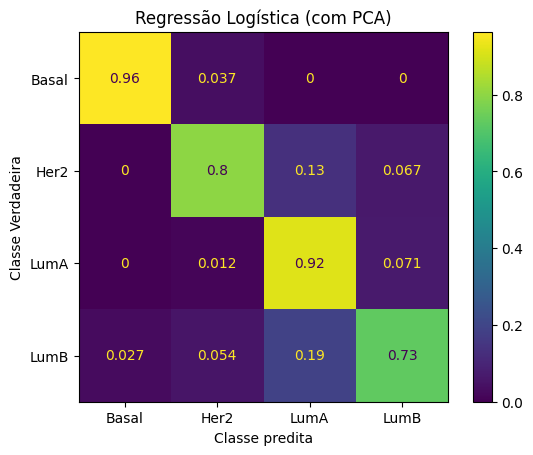

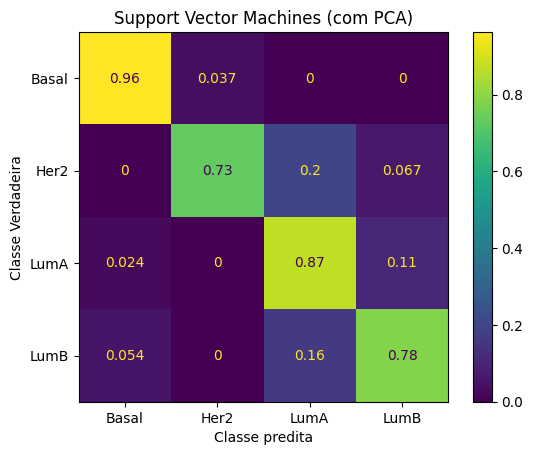

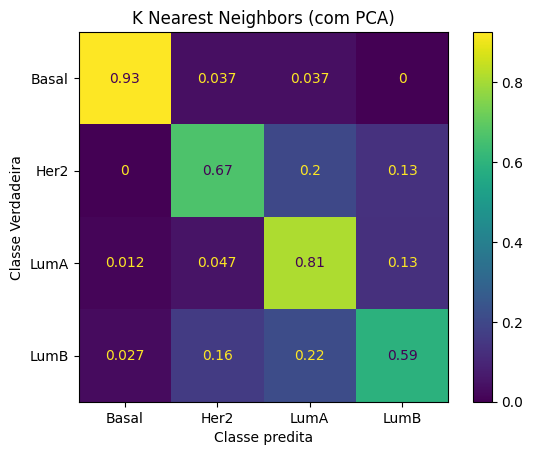

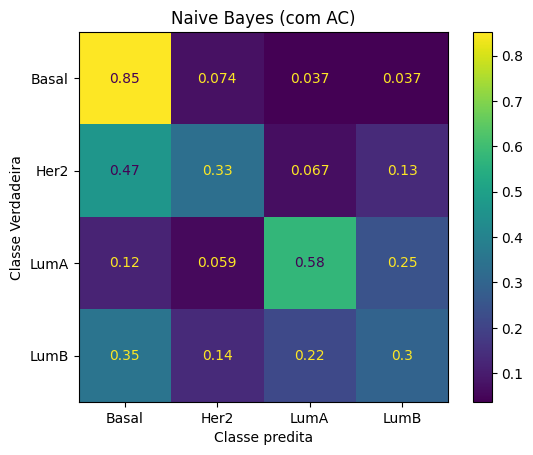

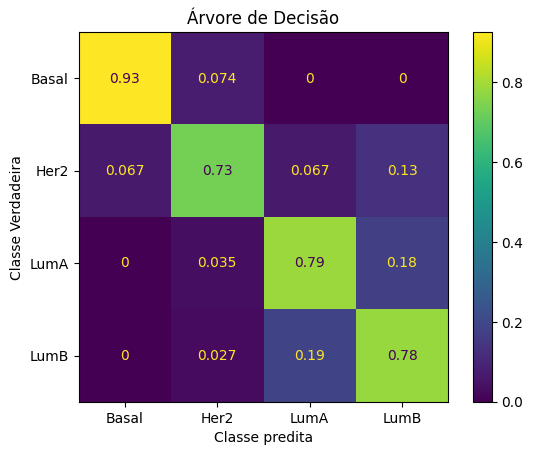

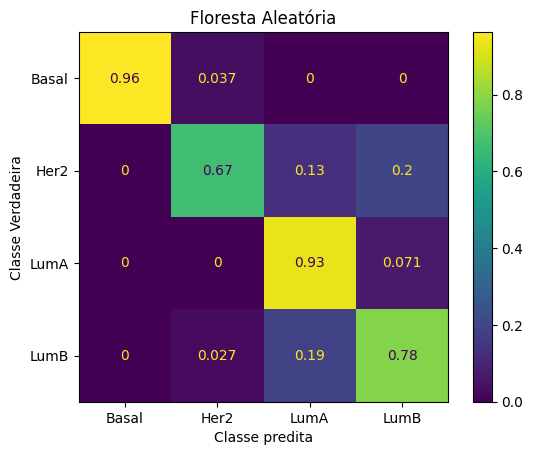

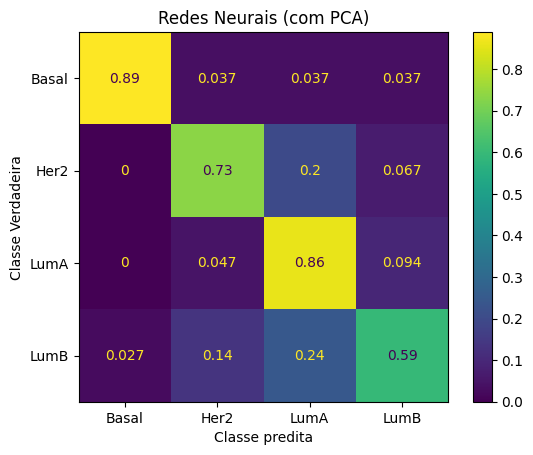

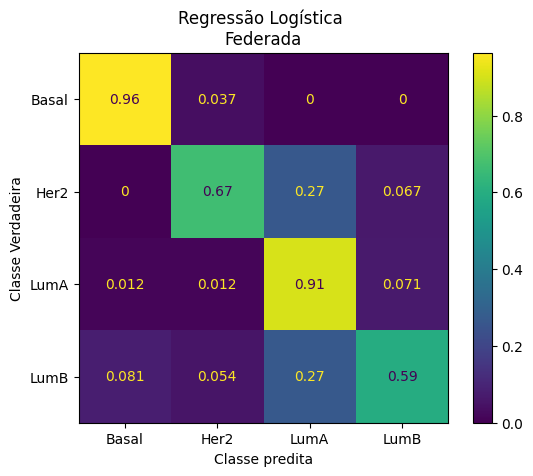

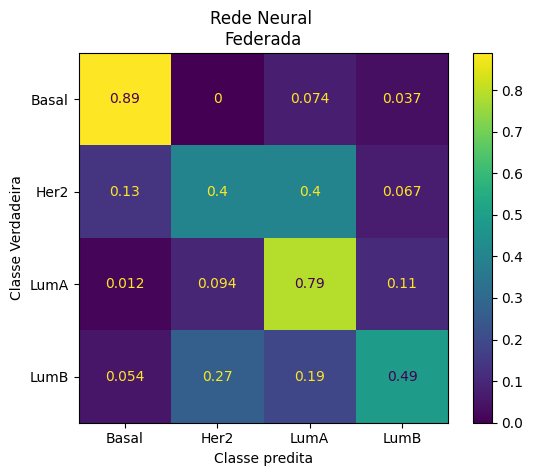

In [ ]:
f1m = [sklearn.metrics.f1_score(y_teste, rl.predict(x_teste_pca_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste, svm.predict(x_teste_pca_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste, knn.predict(x_teste_pca_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste, nb.predict(x_teste_ac_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste, dt.predict(x_teste_sc_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste, rf.predict(x_teste_sc_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste_enc, np.argmax(nn.predict(x_teste_pca_final, verbose = 0), axis = 1), average = 'macro'),
sklearn.metrics.f1_score(y_teste_enc, fl_log_reg.predict(x_teste_subit_final), average = 'macro'),
sklearn.metrics.f1_score(y_teste_enc, np.argmax(fl_nn.predict(x_teste_apc_final, verbose = 0), axis = 1), average = 'macro')]
cmrl = ConfusionMatrixDisplay(confusion_matrix(y_teste, rl.predict(x_teste_pca_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmsvm = ConfusionMatrixDisplay(confusion_matrix(y_teste, svm.predict(x_teste_pca_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmknn = ConfusionMatrixDisplay(confusion_matrix(y_teste, knn.predict(x_teste_pca_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnb = ConfusionMatrixDisplay(confusion_matrix(y_teste, nb.predict(x_teste_ac_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmdt = ConfusionMatrixDisplay(confusion_matrix(y_teste, dt.predict(x_teste_sc_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmrf = ConfusionMatrixDisplay(confusion_matrix(y_teste, rf.predict(x_teste_sc_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnn = ConfusionMatrixDisplay(confusion_matrix(y_teste_enc, np.argmax(nn.predict(x_teste_pca_final, verbose = 0), axis = 1), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmrlfl = ConfusionMatrixDisplay(confusion_matrix(y_teste_enc, fl_log_reg.predict(x_teste_subit_final), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])
cmnnfl = ConfusionMatrixDisplay(confusion_matrix(y_teste_enc, np.argmax(fl_nn.predict(x_teste_apc_final, verbose = 0), axis = 1), normalize='true'), display_labels=['Basal', 'Her2', 'LumA', 'LumB'])

classificadores = [cmrl, cmsvm, cmknn, cmnb, cmdt, cmrf, cmnn, cmrlfl, cmnnfl]
nomes_c = ['Regressão Logística (com PCA)', 'Support Vector Machines (com PCA)', 'K Nearest Neighbors (com PCA)', 'Naive Bayes (com AC)', 'Árvore de Decisão',
           'Floresta Aleatória', 'Redes Neurais (com PCA)', 'Regressão Logística \nFederada', 'Rede Neural \nFederada']
for i in range(len(classificadores)):
    classificadores[i].plot()
    plt.title(nomes_c[i])
    plt.xlabel('Classe predita')
    plt.ylabel('Classe Verdadeira')
    plt.show()

In [ ]:
nomes = ["Regressão Logística", "SVM", "KNN", "Naive Bayes", "Árvore de Decisão", "Floresta Aleatória", "Rede Neural", "Regressão Logística", "Rede Neural"]
tipo = ["Centralizado",  "Centralizado", "Centralizado", "Centralizado", "Centralizado", "Centralizado", "Centralizado", "Federado", "Federado"]
dados_f1 = {
    "Nome": nomes,
    "Tipo": tipo,
    "F1": f1m
}
df_f1 = pd.DataFrame(dados_f1)

In [ ]:
import seaborn as sns

In [ ]:
df_f1.sort_values('F1', ascending=False)

,Nome,Tipo,F1
5,Floresta Aleatória,Centralizado,0.852125
0,Regressão Logística,Centralizado,0.851174
1,SVM,Centralizado,0.842801
4,Árvore de Decisão,Centralizado,0.791798
7,Regressão Logística,Federado,0.785901
6,Rede Neural,Centralizado,0.756418
2,KNN,Centralizado,0.730979
8,Rede Neural,Federado,0.628171
3,Naive Bayes,Centralizado,0.468403


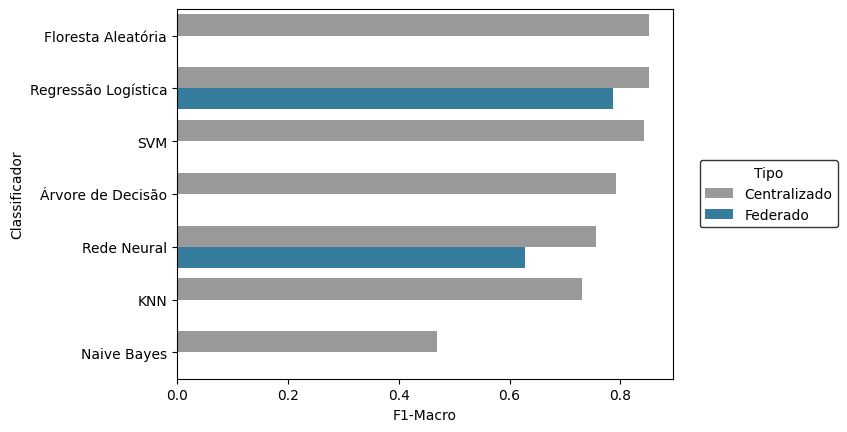

In [ ]:
f1_barras = sns.barplot(data = df_f1.sort_values('F1', ascending=False), x = 'F1', y = 'Nome', hue = 'Tipo', palette=['#999999', '#2582AD'])
sns.move_legend(obj = f1_barras, loc = 'center left', bbox_to_anchor = (1.04,0.5), ncol = 1, edgecolor = 'black')
sns.set_theme(font_scale=1.75, style='white')
plt.ylabel("Classificador")
plt.xlabel("F1-Macro")
plt.savefig('f1_barras_ic.png', bbox_inches = 'tight')

In [ ]:
df_f1.to_csv('df_f1_score.csv')

### Rascunho

In [ ]:
df_feat_imp.sort_values('importance', ascending=False).head(5)

,feature,importance
7886,ENSG00000139865.16,0.007956
17077,ENSG00000196372.13,0.006027
12937,ENSG00000170935.8,0.005780
14571,ENSG00000178935.5,0.005675
9787,ENSG00000154645.14,0.005647


<Axes: xlabel='importance', ylabel='feature'>

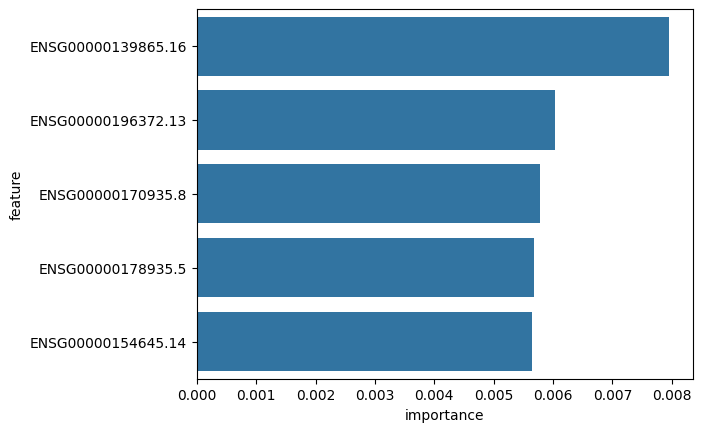

In [ ]:
sns.barplot(data = df_feat_imp.sort_values('importance', ascending=False).head(5), x = 'importance', y = 'feature')